# PV Data Forecasting / Model Comparison

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

from lstm_model import LSTMForecaster

from statsmodels.tsa.arima.model import ARIMA

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler

## Load PV & Weather Data

In [3]:
df = pd.read_csv("data/pv_data.csv", sep=";")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp", inplace=True)
df_solar = df["Solarproduktion"].resample("D").sum()

df_weather = pd.read_csv('data/weather.csv')
df_weather['time'] = pd.to_datetime(df_weather['time'])
df_weather.set_index('time', inplace=True)
df_weather = df_weather.resample('D').mean()

df_join = pd.merge(df_solar, df_weather, left_index=True, right_index=True)
df_join = df_join.rename(columns={"Solarproduktion": "y"}).dropna()

## Prophet Model

In [4]:
prophet_df = df_join.reset_index().rename(columns={'index': 'ds'})
prophet_model = Prophet(seasonality_mode='multiplicative', daily_seasonality=False, yearly_seasonality=True)
prophet_model.fit(prophet_df)

df_cv_prophet = cross_validation(prophet_model, initial='730 days', period='30 days', horizon='30 days', parallel="processes")
prophet_perf = performance_metrics(df_cv_prophet)
print("Prophet Performance Metrics:")
print(prophet_perf.head())

prophet_forecast = prophet_model.predict(prophet_df[-30:])

17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] done processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] done processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chain [1] done processing
17:12:07 - cmdstanpy - INFO - Chain [1] start processing
17:12:07 - cmdstanpy - INFO - Chai

Prophet Performance Metrics:
  horizon           mse          rmse           mae     mdape     smape  \
0  3 days  1.818955e+08  13486.865054  11180.896690  0.312398  0.436921   
1  4 days  1.814689e+08  13471.037806  11427.838722  0.312398  0.435488   
2  5 days  1.435032e+08  11979.282279  10455.837230  0.296363  0.419286   
3  6 days  1.407608e+08  11864.267646  10007.609799  0.293350  0.406247   
4  7 days  1.462204e+08  12092.161735  10121.973695  0.364223  0.463650   

   coverage  
0  0.812500  
1  0.770833  
2  0.812500  
3  0.812500  
4  0.812500  


## ARIMA Model

In [5]:
arima_order = (5, 1, 0)  # p,d,q
train = df_join['y'][:-30]
test = df_join['y'][-30:]

arima_model = ARIMA(train, order=arima_order)
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test))

print("ARIMA MAE:", mean_absolute_error(test, arima_pred))
print("ARIMA RMSE:", np.sqrt(mean_squared_error(test, arima_pred)))

ARIMA MAE: 12576.572826919215
ARIMA RMSE: 16651.39222506173


## Gradient Boosting

In [ ]:
df_lags = df_join.copy()
for lag in range(1, 8):
    df_lags[f'y_lag_{lag}'] = df_lags['y'].shift(lag)
df_lags = df_lags.dropna()
features = [c for c in df_lags.columns if 'y_lag' in c]
X = df_lags[features]
y = df_lags['y']

tscv = TimeSeriesSplit(n_splits=5)
gbr_mae, gbr_rmse = [], []
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    gbr = GradientBoostingRegressor(n_estimators=200, max_depth=3)
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    gbr_mae.append(mean_absolute_error(y_test, y_pred))
    gbr_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))

X_last30 = X.iloc[-30:]
gbr_last30_pred = gbr.predict(X_last30)

## Custom LSTM Model

In [6]:
features = [
    'temperature_2m (°C)',
    'cloud_cover (%)',
    'wind_speed_10m (km/h)',
    'precipitation (mm)',
    'weather_code (wmo code)',
    'relative_humidity_2m (%)',
    'pressure_msl (hPa)',
    'cloud_cover_low (%)',
    'cloud_cover_mid (%)',
    'cloud_cover_high (%)',
    'wind_gusts_10m (km/h)'
]

df_lstm = df_join[['y'] + features].dropna()

y_scaler = MinMaxScaler()
X_scaler = MinMaxScaler()

df_y_scaled = pd.DataFrame(y_scaler.fit_transform(df_lstm[['y']]), columns=['y'])
df_X_scaled = pd.DataFrame(X_scaler.fit_transform(df_lstm[features]), columns=features)

df_scaled = pd.concat([df_y_scaled, df_X_scaled], axis=1)

train_scaled = df_scaled[:-30]
test_scaled = df_scaled[-(30 + 12):]

lstm = LSTMForecaster(lookback_window=12, epochs=100, batch_size=32)
lstm.fit(train_scaled, target_col='y', feature_cols=features)

pred_df_scaled = lstm.predict(test_scaled, target_col='y')

pred_df = pred_df_scaled.copy()
pred_df[['actual', 'predicted']] = y_scaler.inverse_transform(pred_df_scaled[['actual', 'predicted']])

Epoch 1/100 - Loss: 0.1013
Epoch 2/100 - Loss: 0.0532
Epoch 3/100 - Loss: 0.0451
Epoch 4/100 - Loss: 0.0430
Epoch 5/100 - Loss: 0.0402
Epoch 6/100 - Loss: 0.0371
Epoch 7/100 - Loss: 0.0367
Epoch 8/100 - Loss: 0.0349
Epoch 9/100 - Loss: 0.0351
Epoch 10/100 - Loss: 0.0344
Epoch 11/100 - Loss: 0.0328
Epoch 12/100 - Loss: 0.0326
Epoch 13/100 - Loss: 0.0324
Epoch 14/100 - Loss: 0.0323
Epoch 15/100 - Loss: 0.0324
Epoch 16/100 - Loss: 0.0312
Epoch 17/100 - Loss: 0.0312
Epoch 18/100 - Loss: 0.0313
Epoch 19/100 - Loss: 0.0305
Epoch 20/100 - Loss: 0.0301
Epoch 21/100 - Loss: 0.0334
Epoch 22/100 - Loss: 0.0303
Epoch 23/100 - Loss: 0.0299
Epoch 24/100 - Loss: 0.0324
Epoch 25/100 - Loss: 0.0296
Epoch 26/100 - Loss: 0.0298
Epoch 27/100 - Loss: 0.0284
Epoch 28/100 - Loss: 0.0298
Epoch 29/100 - Loss: 0.0302
Epoch 30/100 - Loss: 0.0299
Epoch 31/100 - Loss: 0.0289
Epoch 32/100 - Loss: 0.0291
Epoch 33/100 - Loss: 0.0290
Epoch 34/100 - Loss: 0.0283
Epoch 35/100 - Loss: 0.0280
Epoch 36/100 - Loss: 0.0295
E

## Error Calculation

In [7]:
actual = df_join['y'][-30:]

arima_error = actual - arima_pred
prophet_error = actual.values - prophet_forecast['yhat'].values
gbr_error = actual.values - gbr_last30_pred
lstm_error = actual.values - pred_df['predicted'].values

## Forecast Plot

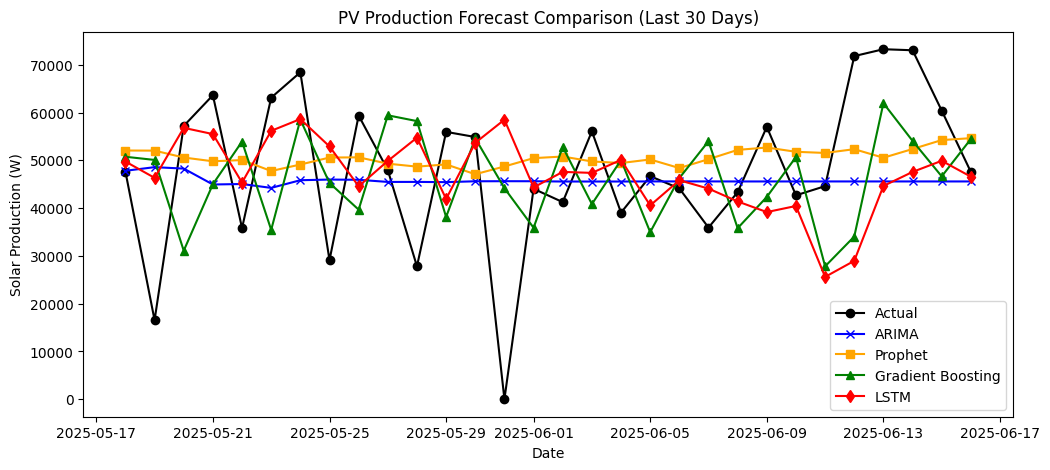

In [12]:
colors = {
    'Actual': 'black',
    'ARIMA': 'blue',
    'Prophet': 'orange',
    'Gradient Boosting': 'green',
    'LSTM': 'red'
}

plt.figure(figsize=(12,5))
plt.plot(actual.index, actual, marker='o', label='Actual', color=colors['Actual'])
plt.plot(actual.index, arima_pred, marker='x', label='ARIMA', color=colors['ARIMA'])
plt.plot(actual.index, prophet_forecast['yhat'], marker='s', label='Prophet', color=colors['Prophet'])
plt.plot(actual.index, gbr_last30_pred, marker='^', label='Gradient Boosting', color=colors['Gradient Boosting'])
plt.plot(actual.index, pred_df['predicted'], marker='d', label='LSTM', color=colors['LSTM'])
plt.title("PV Production Forecast Comparison (Last 30 Days)")
plt.xlabel("Date")
plt.ylabel("Solar Production (W)")
plt.legend()
plt.show()


## Error Plot

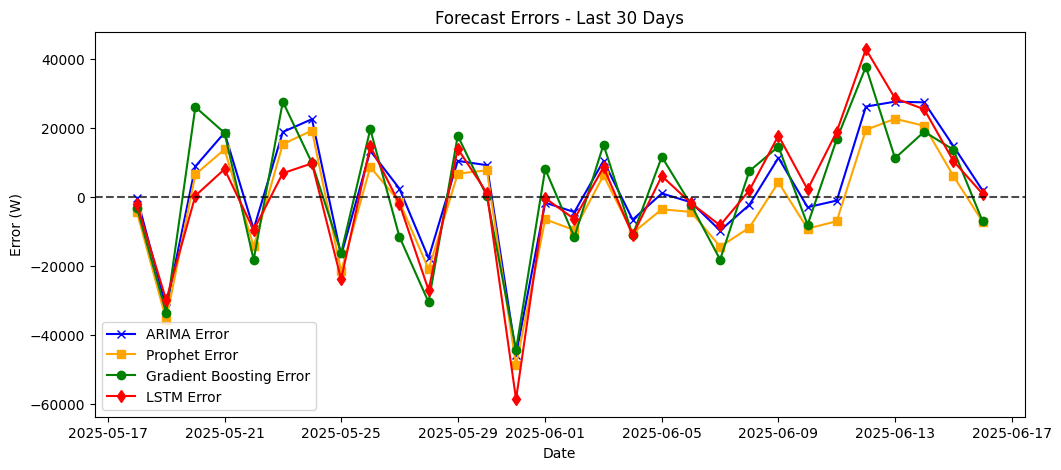

In [13]:
plt.figure(figsize=(12,5))
plt.plot(actual.index, arima_error, marker='x', label='ARIMA Error', color=colors['ARIMA'])
plt.plot(actual.index, prophet_error, marker='s', label='Prophet Error', color=colors['Prophet'])
plt.plot(actual.index, gbr_error, marker='o', label='Gradient Boosting Error', color=colors['Gradient Boosting'])
plt.plot(actual.index, lstm_error, marker='d', label='LSTM Error', color=colors['LSTM'])
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title("Forecast Errors - Last 30 Days")
plt.xlabel("Date")
plt.ylabel("Error (W)")
plt.legend()
plt.show()

In [10]:
print("Summary:")
print("-- Mean Absolute Error -- 30-day mean")
print("\tARIMA -", np.mean(abs(arima_error)))
print("\tProphet -", np.mean(abs(prophet_error)))
print("\tGradient Boosting -", np.mean(abs(gbr_error)))
print("\tLSTM Model -", np.mean(abs(lstm_error)))

Summary:
-- Mean Absolute Error -- 30-day mean
	ARIMA - 12576.572826919213
	Prophet - 12836.283540860308
	Gradient Boosting - 16356.37472551836
	LSTM Model - 13323.501033473014


## Prophet Model Experiments

In [11]:
df = pd.read_csv("data/pv_data.csv", sep=";")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp", inplace=True)

trackers = ["Solarproduktion Tracker 1", "Solarproduktion Tracker 2"]
df_solar = df[trackers + ["Solarproduktion"]].resample("D").sum()

df_weather = pd.read_csv('data/weather.csv')
df_weather['time'] = pd.to_datetime(df_weather['time'])
df_weather.set_index('time', inplace=True)
df_weather = df_weather.resample('D').mean()

df_join = pd.merge(df_solar, df_weather, left_index=True, right_index=True).dropna()

preds_sum_trackers = pd.DataFrame(index=df_join.index[-30:])

for tracker in trackers:
    prophet_df = df_join[[tracker] + features].reset_index().rename(columns={'index':'ds', tracker:'y'})
    prophet_model = Prophet(yearly_seasonality=True, daily_seasonality=False, seasonality_mode='multiplicative')
    prophet_model.fit(prophet_df)
    forecast = prophet_model.predict(prophet_df[-30:])
    preds_sum_trackers[tracker] = forecast['yhat'].values

preds_sum_trackers['sum'] = preds_sum_trackers.sum(axis=1)

prophet_df_direct = df_join.reset_index().rename(columns={'index':'ds', 'Solarproduktion':'y'})
prophet_model_direct = Prophet(yearly_seasonality=True, daily_seasonality=False, seasonality_mode='multiplicative')
prophet_model_direct.fit(prophet_df_direct)
forecast_direct = prophet_model_direct.predict(prophet_df_direct[-30:])

actual = df_join['Solarproduktion'][-30:]
mae_sum_trackers = mean_absolute_error(actual, preds_sum_trackers['sum'])
mae_direct = mean_absolute_error(actual, forecast_direct['yhat'].values)

regressors = ['temperature_2m (°C)', 'relative_humidity_2m (%)']
prophet_df_reg = prophet_df_direct.copy()

prophet_model_reg = Prophet(yearly_seasonality=True, daily_seasonality=False, seasonality_mode='multiplicative')
for reg in regressors:
    prophet_model_reg.add_regressor(reg)

prophet_model_reg.fit(prophet_df_reg)
forecast_reg = prophet_model_reg.predict(prophet_df_reg[-30:])

mae_reg = mean_absolute_error(actual, forecast_reg['yhat'].values)

print("MAE - sum of trackers:", mae_sum_trackers)
print("MAE - direct sum prediction:", mae_direct)
print("MAE - Prophet with regressors:", mae_reg)


12:14:54 - cmdstanpy - INFO - Chain [1] start processing
12:14:54 - cmdstanpy - INFO - Chain [1] done processing
12:14:54 - cmdstanpy - INFO - Chain [1] start processing
12:14:54 - cmdstanpy - INFO - Chain [1] done processing
12:14:54 - cmdstanpy - INFO - Chain [1] start processing
12:14:55 - cmdstanpy - INFO - Chain [1] done processing
12:14:55 - cmdstanpy - INFO - Chain [1] start processing
12:14:55 - cmdstanpy - INFO - Chain [1] done processing


MAE - sum of trackers: 12872.613498275134
MAE - direct sum prediction: 12836.283540860308
MAE - Prophet with regressors: 11128.65712633008
